# Matplotlib 과제

In [38]:
# 한글이 포함된 그래프를 깨지지 않게 표시하기 위한 폰트 설정
import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd

# font_candidates: 운영체제별 한글 폰트 후보
font_candidates = {
    "Darwin": ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Windows": ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}

# available_fonts: 현재 환경에 설치된 폰트 이름 모음
available_fonts = {font.name for font in fm.fontManager.ttflist}

# platform.system(): 현재 운영체제 이름 확인
system_name = platform.system()
selected_font = None

# 폰트 후보 중 실제 설치된 첫 번째 한글 폰트 선택
for font_name in font_candidates.get(system_name, []):
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:

    # font.family: Matplotlib 기본 글꼴 설정
    plt.rcParams["font.family"] = selected_font
    print("설정된 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. NanumGothic 또는 Noto Sans KR 설치가 필요할 수 있습니다.")

# axes.unicode_minus=False: 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False


설정된 한글 폰트: Malgun Gothic


## [실습 1] 다양한 그래프 활용 1

주어진 데이터에 대해 다음 그래프를 하나의 Figure에 배치.

1. 선 그래프
2. 막대 그래프
3. 히스토그램
4. 산점도

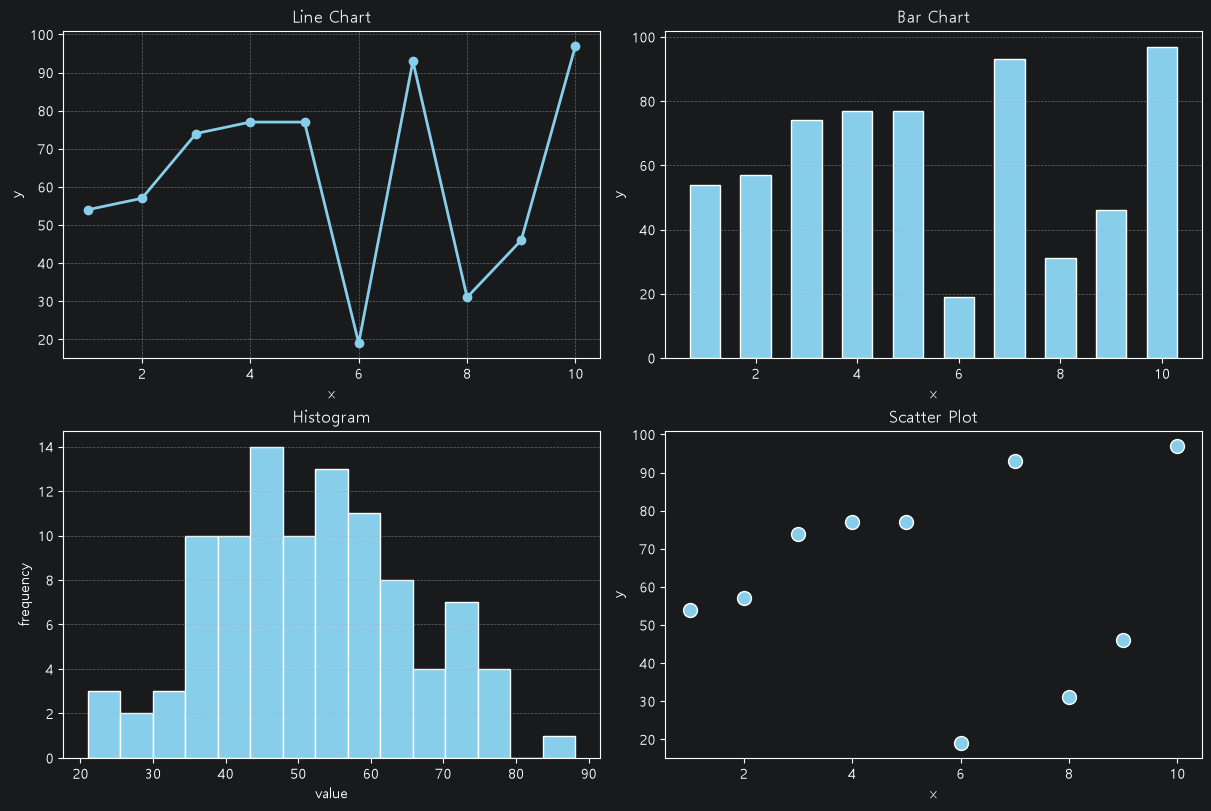

In [39]:
np.random.seed(0)
# x: 1부터 10까지의 정수 배열
# y: 10부터 99까지의 정수 중 10개를 무작위 생성
x = np.arange(1, 11)
y = np.random.randint(10, 100, 10)

# data: 평균 50, 표준편차 15인 정규분포 데이터 100개 생성
# 히스토그램으로 값의 분포를 확인하기 위한 데이터
data = np.random.normal(50, 15, 100)

# plt.subplots(): 여러 그래프를 배치할 Figure와 Axes 생성
# 2, 2: 2행 2열 배치
# figsize=(12, 8): 전체 Figure 크기
# constrained_layout=True: 그래프끼리 겹치지 않도록 간격 자동 조정
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# 1. 선 그래프: x 변화에 따른 y의 변화 흐름 확인
axes[0, 0].plot(x, y, color='skyblue', marker='o', linewidth=2, markersize=6)
axes[0, 0].set_title('Line Chart')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].grid(True, linestyle='dashed', alpha=0.5)
plt.grid()

# 2. 막대 그래프: x별 y 크기 비교
axes[0, 1].bar(x, y, color='skyblue', edgecolor='white', width=0.6)
axes[0, 1].set_title('Bar Chart')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y')
axes[0, 1].grid(axis='y', linestyle='dashed', alpha=0.5)
plt.grid()

# 3. 히스토그램: data가 어떤 구간에 많이 몰려 있는지 확인
axes[1, 0].hist(data, bins=15, color='skyblue', edgecolor='white')
axes[1, 0].set_title('Histogram')
axes[1, 0].set_xlabel('value')
axes[1, 0].set_ylabel('frequency')
axes[1, 0].grid(axis='y', linestyle='dashed', alpha=0.5)
plt.grid()

# 4. 산점도: x와 y의 관계를 점으로 확인
axes[1, 1].scatter(x, y, color='skyblue', s=100, edgecolors='white', linewidths=1)
axes[1, 1].set_title('Scatter Plot')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('y')
axes[1, 1].grid(True, linestyle='dashed', alpha=0.5)
plt.grid()

plt.show()

## [실습 2] 다양한 그래프 활용 2

월별 평균 기온, 월별 강수량, 학생들의 수학/영어 점수를 이용해 그래프를 작성.

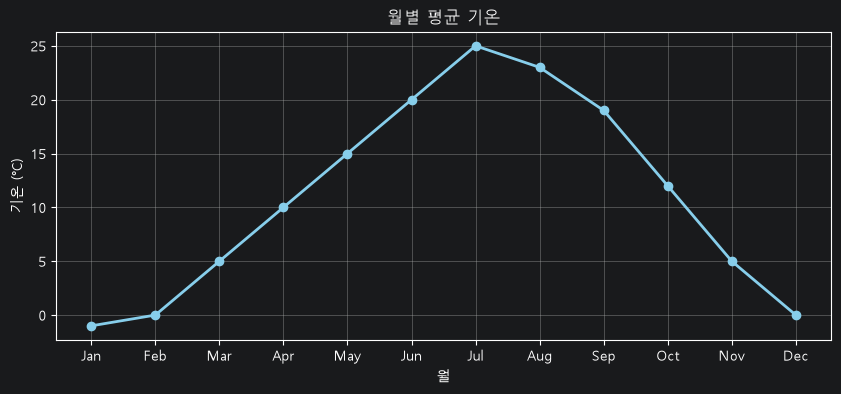

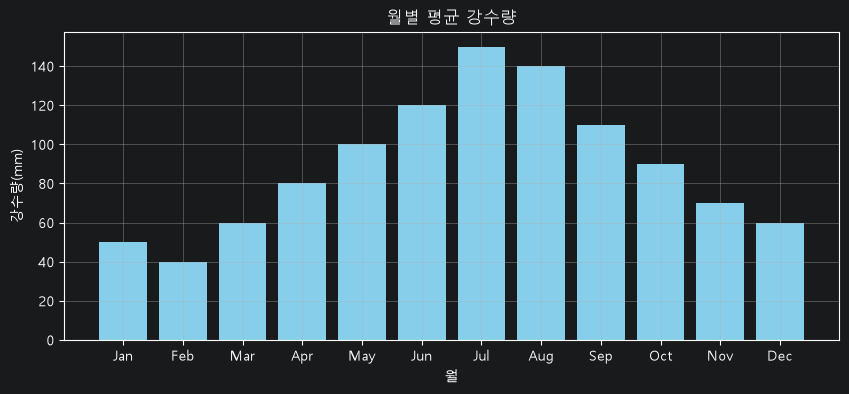

In [40]:
# 실습 2 그래프 작성에 사용할 데이터 준비
months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
avg_temperatures = [-1, 0, 5, 10, 15, 20, 25, 23, 19, 12, 5, 0]
rainfall = [50, 40, 60, 80, 100, 120, 150, 140, 110, 90, 70, 60]

math_scores = [85, 90, 88, 76, 95, 89, 72, 84, 91, 87]
english_scores = [78, 82, 85, 80, 88, 90, 84, 79, 85, 83]

# 긴 월 이름이 x축에서 겹칠 수 있으므로 약어를 별도로 생성
month_labels = [month[:3] for month in months]

# 1. 월평균 기온
plt.figure(figsize=(10, 4))
plt.plot(month_labels, avg_temperatures, marker='o', color='skyblue', linewidth=2)
plt.title("월별 평균 기온")
plt.xlabel("월")
plt.ylabel("기온 (°C)")
plt.grid()
plt.show()

# 2.월 평균 강수량
plt.figure(figsize=(10, 4))
plt.bar(month_labels, rainfall, color='skyblue', alpha=1)
plt.title("월별 평균 강수량")
plt.xlabel("월")
plt.ylabel("강수량(mm)")
plt.grid()
plt.show()


### 1. 월별 평균 기온 선 그래프
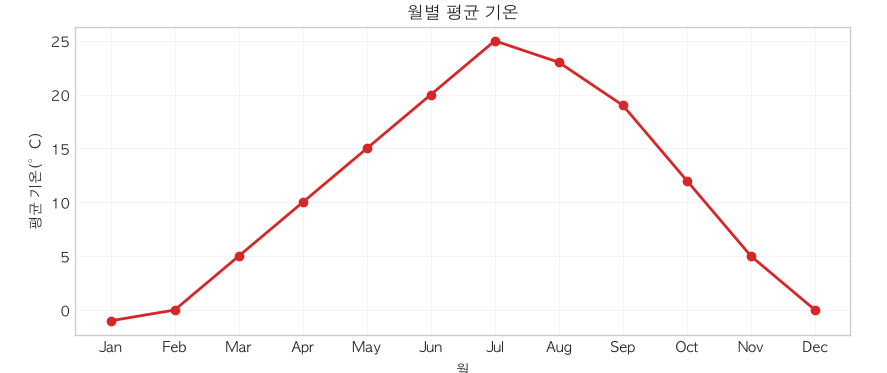

In [41]:
plt.figure(figsize=(10, 4))



plt.show()

<Figure size 1000x400 with 0 Axes>

### 2. 월별 강수량 막대 그래프

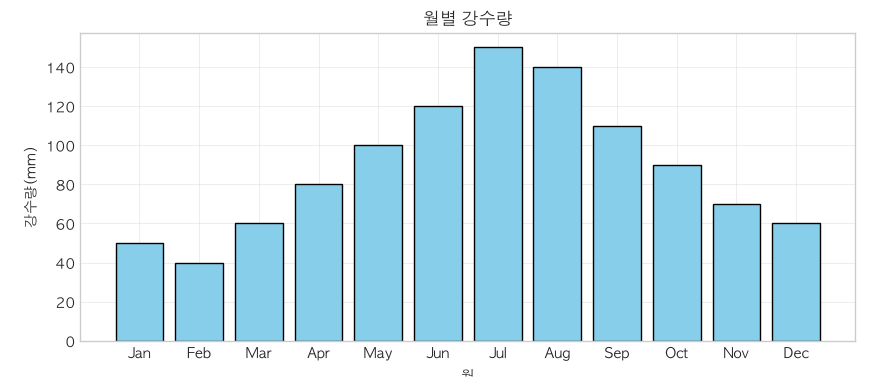

In [42]:
plt.figure(figsize=(10, 4))


plt.show()

<Figure size 1000x400 with 0 Axes>

### 3. 수학과 영어 점수 박스플롯

- 두 과목 점수의 중앙값, 퍼짐 정도, 이상값 후보를 비교.
- 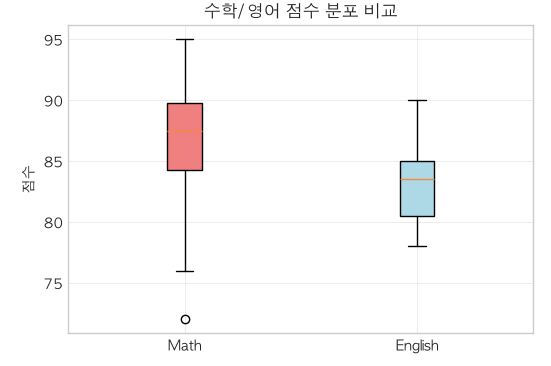

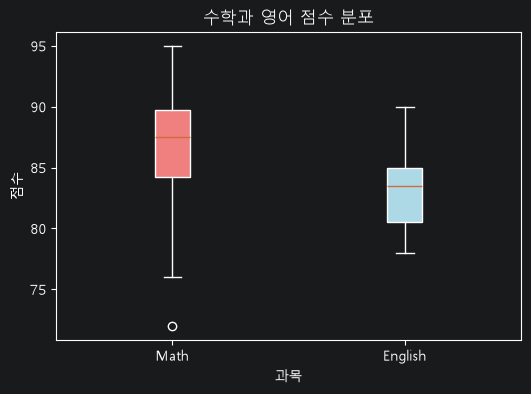

In [43]:
math_scores = [85, 90, 88, 76, 95, 89, 72, 84, 91, 87]
english_scores = [78, 82, 85, 80, 88, 90, 84, 79, 85, 83]

plt.figure(figsize=(6, 4))

class_scores_df = pd.DataFrame({
    "math_scores" : [85, 90, 88, 76, 95, 89, 72, 84, 91, 87],
    "english_scores" : [78, 82, 85, 80, 88, 90, 84, 79, 85, 83]
})

box = plt.boxplot(
    class_scores_df,
    patch_artist=True,
    boxprops={'facecolor':'skyblue'}
)

colors = ['lightcoral', 'lightblue']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('수학과 영어 점수 분포')
plt.xlabel('과목')
plt.ylabel('점수')

plt.xticks([1,2], ['Math', 'English'])

plt.show()

### 4. 수학 점수 히스토그램

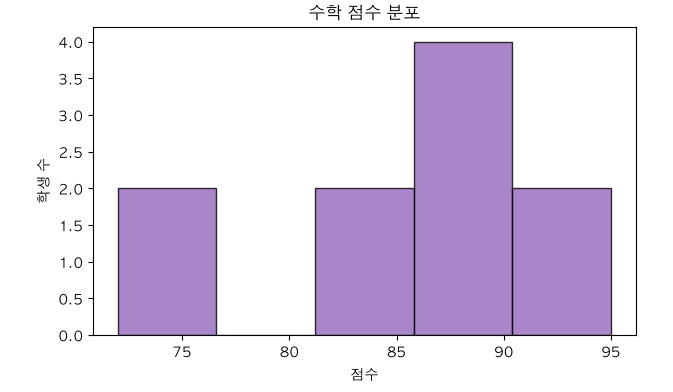

In [ ]:
plt.figure(figsize=(7, 4))


plt.show()

### 5. 수학 점수와 영어 점수 산점도

- 수학 점수가 높은 학생이 영어 점수도 높은 경향이 있는지 확인.
- 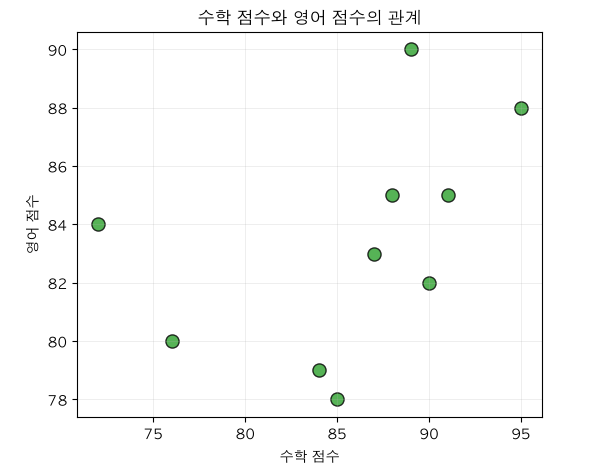

In [ ]:
plt.figure(figsize=(6, 5))


plt.show()

### 6. 1~5의 모든 그래프를 하나의 Figure에 배치



In [ ]:
# 목적: 실습 2의 5개 그래프를 하나의 Figure에 모아서 표시
fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

# axes.ravel()
# - 2차원 형태의 axes 배열을 1차원으로 펼침
# - axes[0,0], axes[0,1]  -> axes[0], axes[1] 간단히 접근 가능
axes = axes.ravel()


# 2행 3열 중 마지막 칸은 사용하지 않으므로 숨김
axes[5].axis("off")
plt.show()